# Predicting a WR's jump: who will beat his own track record next season?

**Example:** Jaxon Smith-Njigba went 8.8 → 14.9 → 21.2 PPR points per game from 2023 to 2025. Could his rise have been seen coming?

**Approach**
1. **Baseline** = what a player has already shown: his PPR points per game over the last two seasons, weighted by games played.
2. **Target** = next season's points per game **minus** that baseline. Positive = he outperformed his track record.
3. **Two models**, both scored only on seasons they never saw (train on past seasons, predict the next one):
   - **How much will he change?** (ridge regression on the PPG change)
   - **Will he make a big leap?** (logistic regression on: +4 PPG over baseline **and** at least 14 PPG, roughly WR2 territory)
4. Score the 2025 seasons to produce **2026 predictions**. 2026 results are the holdout and are never used.

Data: `data/processed/player_seasons.parquet` (built by `build_player_seasons.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = pd.read_parquet("../data/processed/player_seasons.parquet")
wr = df[df["position"] == "WR"].copy()

# Baseline: games-weighted PPR per game over this season and the one before it
prev = (wr[["player_id", "season", "ppr", "games"]]
        .assign(season=lambda x: x["season"] + 1)
        .rename(columns={"ppr": "prev_ppr", "games": "prev_games"}))
wr = wr.merge(prev, on=["player_id", "season"], how="left")
wr["baseline_ppg"] = (wr["ppr"] + wr["prev_ppr"].fillna(0)) / (wr["games"] + wr["prev_games"].fillna(0))

# Helper features
wr["draft_pick_filled"] = wr["draft_pick"].fillna(300)                                   # undrafted = 300
wr["depth_promotion"] = wr["preseason_depth_tier"] - wr["next_preseason_depth_tier"]     # + = moved up the depth chart

# Who's eligible: a real role this season (6+ games, 100+ routes)
pool = wr[(wr["games"] >= 6) & (wr["routes"] >= 100)].copy()

# Labeled seasons: we know what happened next year (2016-2024 seasons)
lab = pool[(pool["season"] <= 2024) & (pool["next_games"] >= 6)].copy()
lab["ppg_change"] = lab["next_ppr_per_game"] - lab["baseline_ppg"]
lab["leap"] = ((lab["ppg_change"] >= 4) & (lab["next_ppr_per_game"] >= 14)).astype(int)
print(f"{len(lab)} WR seasons | average change {lab['ppg_change'].mean():+.2f} PPG | big leaps: {lab['leap'].sum()} ({lab['leap'].mean():.1%})")

974 WR seasons | average change -0.43 PPG | big leaps: 48 (4.9%)


## Why the baseline matters: regression to the mean

The higher a player's baseline, the more he tends to *fall* the next year. Any model has to account for this, or it will just "predict" that bad players improve and good players decline.

In [2]:
lab["baseline_bucket"] = pd.cut(lab["baseline_ppg"], [0, 6, 9, 12, 15, 18, 30])
lab.groupby("baseline_bucket", observed=True).agg(
    players=("ppg_change", "size"), avg_change=("ppg_change", "mean"), leap_rate=("leap", "mean")).round(2)

,players,avg_change,leap_rate
baseline_bucket,,,
"(0, 6]",260,0.91,0.01
"(6, 9]",235,-0.46,0.03
"(9, 12]",186,-1.13,0.06
"(12, 15]",165,-0.92,0.08
"(15, 18]",87,-1.19,0.09
"(18, 30]",41,-2.03,0.10


## The factors

| Group | Features |
|---|---|
| **Track record** | `baseline_ppg`, `ppr_per_game`, `second_half_trend` |
| **Talent / efficiency** | targets per route run (`tprr`), yards per route run (`yprr`), points over expected (`fp_over_expected_per_game`), `adot` |
| **Current role** | `target_share`, `route_participation`, `xfp_per_game`, `rz_target_share` |
| **Career stage** | `age`, `years_exp`, `draft_pick_filled` |
| **Next season's opportunity** | `next_team_vacated_target_share`, `next_preseason_depth_tier`, `depth_promotion`, `changed_team` |
| **Environment** | `qb_epa_per_dropback`, `team_pass_rate_over_exp`, `next_sos_pass_def_epa` (schedule), `games_missed` |

Missing values (e.g., no depth chart listing) are filled with the median, and the model is told they were missing.

In [3]:
FEATURES = ["baseline_ppg", "ppr_per_game", "second_half_trend",
            "tprr", "yprr", "fp_over_expected_per_game", "adot",
            "target_share", "route_participation", "xfp_per_game", "rz_target_share",
            "age", "years_exp", "draft_pick_filled",
            "next_team_vacated_target_share", "next_preseason_depth_tier", "depth_promotion", "changed_team",
            "qb_epa_per_dropback", "team_pass_rate_over_exp", "next_sos_pass_def_epa", "games_missed"]

def change_model():
    return make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(), Ridge(alpha=10))

def leap_model():
    return make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler(),
                         LogisticRegression(C=0.5, max_iter=2000))

## Backtest: predict each season using only earlier seasons

For every season from 2019 to 2024, train on all earlier seasons, then predict that season's players. This mimics using the model in real time, with no peeking at the future.

In [4]:
results = []
for season in range(2019, 2025):
    train, test = lab[lab["season"] < season], lab[lab["season"] == season]
    out = test[["name", "season", "team", "baseline_ppg", "next_ppr_per_game", "ppg_change", "leap",
                "next_preseason_rank"]].copy()
    out["pred_change"] = change_model().fit(train[FEATURES], train["ppg_change"]).predict(test[FEATURES])
    out["leap_prob"] = leap_model().fit(train[FEATURES], train["leap"]).predict_proba(test[FEATURES])[:, 1]
    results.append(out)
bt = pd.concat(results)

naive = bt["ppg_change"].abs().mean()            # "he'll match his baseline"
model = (bt["ppg_change"] - bt["pred_change"]).abs().mean()
print(f"Average miss on next-season PPG: naive {naive:.2f} vs model {model:.2f}")
print(f"Correlation of predicted vs actual change: {np.corrcoef(bt['pred_change'], bt['ppg_change'])[0, 1]:.2f}")
print(f"Leap model AUC: {roc_auc_score(bt['leap'], bt['leap_prob']):.2f}  (0.5 = coin flip, 1.0 = perfect)")

Average miss on next-season PPG: naive 2.86 vs model 2.57
Correlation of predicted vs actual change: 0.42
Leap model AUC: 0.76  (0.5 = coin flip, 1.0 = perfect)


### Does the predicted change line up with what actually happened?

Players are split into 10 equal groups by predicted change (decile 1 = model expects the biggest drop, 10 = biggest rise).

In [5]:
bt["decile"] = bt.groupby("season")["pred_change"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False) + 1)
deciles = bt.groupby("decile").agg(predicted=("pred_change", "mean"), actual=("ppg_change", "mean"),
                                   leap_rate=("leap", "mean"), players=("leap", "size"))
deciles.round(2)

,predicted,actual,leap_rate,players
decile,,,,
1,-3.38,-3.07,0.03,69
2,-2.00,-2.30,0.03,65
3,-1.29,-1.63,0.03,65
4,-0.74,-0.83,0.05,65
5,-0.32,-0.71,0.06,66
6,0.14,-0.24,0.03,65
7,0.53,-0.48,0.05,65
8,0.94,0.04,0.05,65
9,1.45,1.30,0.08,65


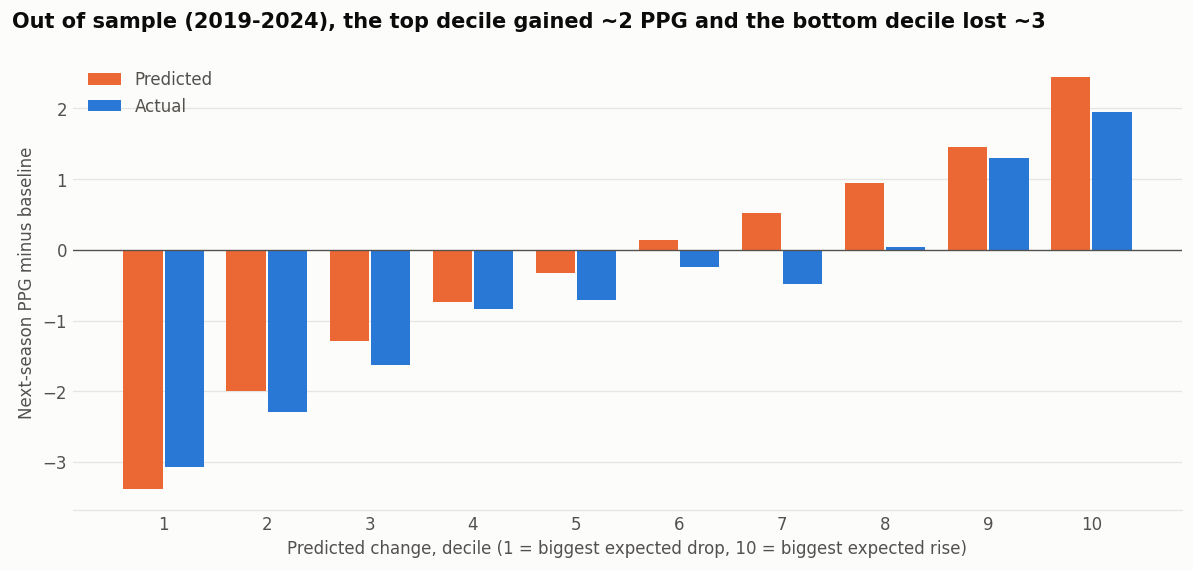

In [6]:
SURF, INK, INK2, GRID, BLUE, ORANGE = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1", "#2a78d6", "#eb6834"
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=120)
fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)
x = np.arange(1, 11); w = 0.38
ax.bar(x - w/2 - 0.01, deciles["predicted"], w, color=ORANGE, label="Predicted")
ax.bar(x + w/2 + 0.01, deciles["actual"], w, color=BLUE, label="Actual")
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f"{i}" for i in x])
ax.set_xlabel("Predicted change, decile (1 = biggest expected drop, 10 = biggest expected rise)", color=INK2)
ax.set_ylabel("Next-season PPG minus baseline", color=INK2)
fig.suptitle("Out of sample (2019-2024), the top decile gained ~2 PPG and the bottom decile lost ~3",
             x=0.01, ha="left", color=INK, fontsize=12.5, fontweight="bold")
ax.legend(frameon=False, loc="upper left", labelcolor=INK2)
ax.grid(axis="y", color=GRID); ax.set_axisbelow(True)
for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=INK2, length=0)
plt.tight_layout(); plt.show()

## What drives a jump?

Model weights after training on all 2016-2024 seasons. All features are standardized, so the bars are comparable: each is the PPG change associated with a one-standard-deviation increase, **holding the others constant**.

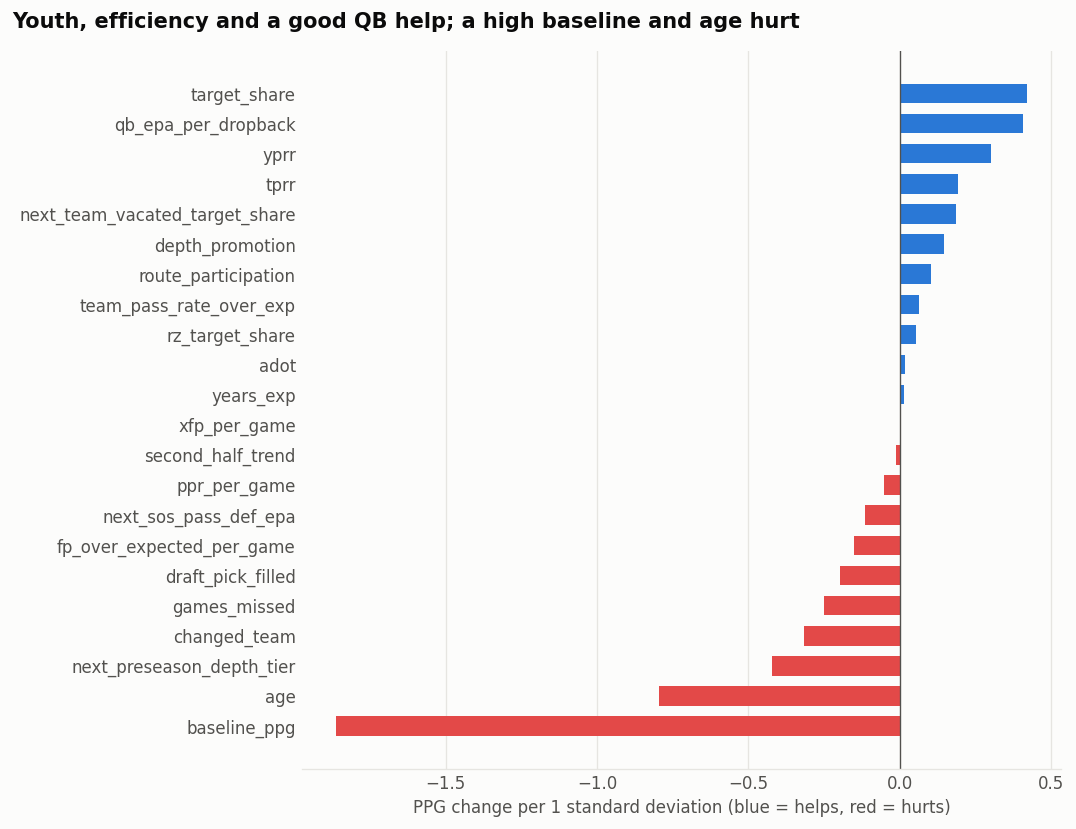

In [7]:
final_change = change_model().fit(lab[FEATURES], lab["ppg_change"])
weights = pd.Series(final_change[-1].coef_[:len(FEATURES)], index=FEATURES).sort_values()

RED = "#e34948"
fig, ax = plt.subplots(figsize=(9, 7), dpi=120)
fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)
ax.barh(weights.index, weights.values, color=[BLUE if v > 0 else RED for v in weights.values], height=0.65)
ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlabel("PPG change per 1 standard deviation (blue = helps, red = hurts)", color=INK2)
fig.suptitle("Youth, efficiency and a good QB help; a high baseline and age hurt",
             x=0.01, ha="left", color=INK, fontsize=12.5, fontweight="bold")
ax.grid(axis="x", color=GRID); ax.set_axisbelow(True)
for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=INK2, length=0)
plt.tight_layout(); plt.show()

## Case study: Jaxon Smith-Njigba (and two other risers)

`pct` = where the model ranked the player's predicted change among all WRs that season (1.00 = top).

In [8]:
bt["pct"] = bt.groupby("season")["pred_change"].rank(pct=True)
bt[bt["name"].isin(["Jaxon Smith-Njigba", "Puka Nacua", "Nico Collins"])][
    ["name", "season", "baseline_ppg", "next_ppr_per_game", "ppg_change", "pred_change", "pct", "leap_prob"]
].sort_values(["name", "season"]).round(2)

,name,season,baseline_ppg,next_ppr_per_game,ppg_change,pred_change,pct,leap_prob
1657,Jaxon Smith-Njigba,2023,8.81,14.88,6.07,2.38,0.95,0.16
1843,Jaxon Smith-Njigba,2024,11.85,21.17,9.32,1.24,0.79,0.12
1201,Nico Collins,2021,5.97,9.71,3.74,2.56,0.96,0.18
1447,Nico Collins,2022,7.53,17.36,9.83,1.50,0.82,0.11
1621,Nico Collins,2023,14.30,17.55,3.25,0.24,0.62,0.28
1857,Nico Collins,2024,17.44,15.08,-2.36,-2.04,0.20,0.09
1613,Puka Nacua,2023,17.56,18.78,1.22,-0.08,0.55,0.31
1860,Puka Nacua,2024,18.04,23.44,5.40,-0.65,0.41,0.51


## 2026 predictions

Both models retrained on every labeled season (2016-2024), then applied to 2025 seasons. `next_preseason_rank` is where FantasyPros experts ranked him before the 2026 season. A high predicted change with a low market rank is a potential diamond.

In [9]:
final_leap = leap_model().fit(lab[FEATURES], lab["leap"])
now = pool[pool["season"] == 2025].copy()
now["pred_change_2026"] = final_change.predict(now[FEATURES])
now["pred_ppg_2026"] = now["baseline_ppg"] + now["pred_change_2026"]
now["leap_prob_2026"] = final_leap.predict_proba(now[FEATURES])[:, 1]
cols = ["name", "team", "age", "baseline_ppg", "pred_ppg_2026", "pred_change_2026", "leap_prob_2026",
        "tprr", "yprr", "next_team_vacated_target_share", "next_preseason_team", "next_preseason_rank"]
# Most likely to make a big leap in 2026
now.sort_values("leap_prob_2026", ascending=False)[cols].head(12).round(2)

,name,team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,tprr,yprr,next_team_vacated_target_share,next_preseason_team,next_preseason_rank
2072,Jaxon Smith-Njigba,SEA,23.5,18.03,18.28,0.26,0.41,0.34,3.71,0.08,SEA,3.0
2119,Luther Burden III,CHI,21.7,8.53,10.88,2.36,0.37,0.25,2.72,0.30,CHI,22.0
2077,Zay Flowers,BAL,25.0,13.32,13.68,0.37,0.26,0.25,2.54,0.18,BAL,15.0
2085,Tetairoa McMillan,CAR,22.4,12.55,13.41,0.85,0.24,0.22,1.86,0.16,CAR,19.0
2071,Puka Nacua,LA,24.3,21.54,19.54,-2.00,0.21,0.36,3.67,0.00,LA,2.0
2093,Emeka Egbuka,TB,22.9,11.51,13.06,1.54,0.16,0.24,1.77,0.31,TB,21.0
2143,Adonai Mitchell,NYJ,22.9,4.29,7.55,3.26,0.15,0.24,1.46,0.25,NYJ,60.0
2089,Drake London,ATL,24.1,16.64,15.70,-0.95,0.15,0.28,2.34,0.32,ATL,7.0
2084,Wan'Dale Robinson,NYG,24.7,12.14,12.09,-0.05,0.15,0.26,1.87,0.29,TEN,37.0
2132,Garrett Wilson,NYJ,25.1,14.64,13.03,-1.61,0.14,0.26,1.77,0.25,NYJ,16.0


Raw predicted *change* favors players starting from almost nothing (4 → 7 PPG isn't useful in fantasy), so the riser list below only includes WRs who already have a real role (baseline 9+ PPG).

In [10]:
now[now["baseline_ppg"] >= 9].sort_values("pred_change_2026", ascending=False)[cols].head(12).round(2)

,name,team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,tprr,yprr,next_team_vacated_target_share,next_preseason_team,next_preseason_rank
2097,Parker Washington,JAX,23.4,9.39,11.15,1.76,0.10,0.23,2.09,0.29,JAX,28.0
2111,Rome Odunze,CHI,23.2,10.03,11.68,1.65,0.12,0.22,1.62,0.30,CHI,29.0
2093,Emeka Egbuka,TB,22.9,11.51,13.06,1.54,0.16,0.24,1.77,0.31,TB,21.0
2129,Xavier Worthy,KC,22.3,9.90,11.29,1.38,0.09,0.18,1.28,0.32,KC,54.0
2116,Christian Watson,GB,26.3,9.90,11.22,1.32,0.12,0.23,2.54,0.37,GB,27.0
2085,Tetairoa McMillan,CAR,22.4,12.55,13.41,0.85,0.24,0.22,1.86,0.16,CAR,19.0
2113,Josh Downs,IND,24.1,10.73,11.57,0.84,0.07,0.23,1.51,0.26,IND,39.0
2107,Romeo Doubs,GB,25.4,10.26,10.66,0.40,0.02,0.21,1.77,0.37,NE,53.0
2098,Alec Pierce,IND,25.3,11.12,11.50,0.38,0.06,0.18,2.12,0.26,IND,43.0
2077,Zay Flowers,BAL,25.0,13.32,13.68,0.37,0.26,0.25,2.54,0.18,BAL,15.0


In [11]:
# Potential diamonds: market ranked them outside the top 36, sorted by predicted 2026 PPG
now[now["next_preseason_rank"] > 36].sort_values("pred_ppg_2026", ascending=False)[cols].head(10).round(2)

,name,team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,tprr,yprr,next_team_vacated_target_share,next_preseason_team,next_preseason_rank
2084,Wan'Dale Robinson,NYG,24.7,12.14,12.09,-0.05,0.15,0.26,1.87,0.29,TEN,37.0
2105,Quentin Johnston,LAC,24.0,12.35,11.85,-0.50,0.04,0.17,1.51,0.30,LAC,42.0
2083,Courtland Sutton,DEN,29.9,13.94,11.80,-2.14,0.02,0.20,1.64,0.01,DEN,38.0
2113,Josh Downs,IND,24.1,10.73,11.57,0.84,0.07,0.23,1.51,0.26,IND,39.0
2087,Stefon Diggs,NE,31.8,13.29,11.52,-1.76,0.02,0.25,2.46,0.52,WAS,41.0
2098,Alec Pierce,IND,25.3,11.12,11.50,0.38,0.06,0.18,2.12,0.26,IND,43.0
2129,Xavier Worthy,KC,22.3,9.90,11.29,1.38,0.09,0.18,1.28,0.32,KC,54.0
2102,Jakobi Meyers,JAX,28.8,12.70,11.23,-1.47,0.02,0.21,1.59,0.29,JAX,48.0
2106,Khalil Shakir,BUF,25.6,11.25,11.21,-0.05,0.05,0.22,1.60,0.16,BUF,50.0
2115,Jordan Addison,MIN,23.6,11.99,11.00,-0.98,0.05,0.18,1.38,0.18,MIN,47.0


## Takeaways

1. **The change model works, modestly.** Out of sample it beats "he'll repeat his baseline", and its top-decile players really did improve the most on average.
2. **Biggest drivers:** a *low* baseline (regression to the mean), **youth**, a good QB, high target share and efficiency (yards and targets per route run), and opportunity next year (depth-chart promotion, vacated targets). Changing teams tends to hurt.
3. **Big leaps are hard to call.** Only about 5% of WR seasons are leaps, so even a decent model (AUC ~0.75) produces many false alarms. Use leap probability to build a shortlist, not as a sure thing.
4. **JSN:** the model ranked his 2023→2024 rise in the top 5% of WRs. His 2025 jump (+9.3 PPG) was predicted in the right direction (top ~20%) but far smaller. A new QB and the departures of DK Metcalf and Tyler Lockett (46% of Seattle's targets vacated) helped, but leaps that big are mostly unpredictable.

**Next steps:** add coordinator features once `reference/coordinators.csv` exists; build RB and TE versions; grade the 2026 predictions at season's end.